# **DEPRECATED: Simulation Tool 2026**

In [2]:
project = "CANSAT"

## Installs

In this section all needed libraries are installed and the needed classes imported

In [126]:
%pip install rocketpy==1.11.0

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wattikan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
%pip install CoolProp

^C
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wattikan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import sys
import copy
import datetime
import itertools
import numpy as np
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt

from math import prod, pi
from matplotlib.path import Path
from matplotlib.patches import Polygon
from datetime import datetime, timedelta
from rocketpy import Environment, SolidMotor, Rocket, Flight, Fluid, LiquidMotor, CylindricalTank, MassFlowRateBasedTank, TrapezoidalFins, FreeFormFins, RailButtons, NoseCone, Tail, Parachute, CompareFlights

from simulation.simulation import *
from simulation.deployable_payload import *

# Simulation

## Configuration

The length unit chosen here is millimeters to keep the values more readable. If necessary, values should be converted accordingly.

Config rules:

#comment

date=(2025, 10, 12, 17, 00, 00)                                                 #tuple

fins_shape_points=((0,0),(0.250,-0.012),(0.250, 0.108),(0.195, 0.108),(0,0))    #tuple of tuples

fins_span=110..120:2                                                            #range with increments of 2 (incl 110, excl.120)

fins_sweep_length=193, 180, 200                                                 # variable with discrete values (integer)

thrust=thrust_euroc_launch.csv,thrust.csv, thrust_08_25.csv                     #variable with discrete values (string)

everything else is a constant
latitude=39.232465                                                              #constant


In [ ]:
# returns a range of floats
def float_range(start, stop, step=1):
    while start <= stop:
        yield start
        start += step

# function to parse different types of parameters in config
def parse_value(value_str):
    """Parse a value into constant or list of values."""
    value_str = value_str.strip()

    # Tuple of tuples
    if "((" in value_str and "))" in value_str:
        value_str = value_str.strip("()")
        items = value_str.split("),(")
        parsed_items = []
        for item in items:
            item = item.strip("()")
            sub_items = [v.strip() for v in item.split(",")]
            sub_parsed_items = []
            for sub_item in sub_items:
                try:
                    n = float(sub_item)
                    sub_parsed_items.append(int(n) if n.is_integer() else n)
                except ValueError:
                    sub_parsed_items.append(sub_item)
            parsed_items.append(tuple(sub_parsed_items))
        return tuple(parsed_items)
    
    # Tuple of values
    if "(" in value_str and ")" in value_str:
        value_str = value_str.strip("()")
        items = [v.strip() for v in value_str.split(",")]
        parsed_items = []
        for item in items:
            try:
                n = float(item)
                parsed_items.append(int(n) if n.is_integer() else n)
            except ValueError:
                parsed_items.append(item)
        return tuple(parsed_items)
    
    if ".." in value_str:
        value_str, step = value_str.split(":")
        start, end = map(float, value_str.split(".."))
        return list(float_range(start, end, float(step)))

    # Comma-separated variable values
    if "," in value_str:
        items = [v.strip() for v in value_str.split(",")]
        parsed_items = []
        for item in items:
            try:
                n = float(item)
                parsed_items.append(int(n) if n.is_integer() else n)
            except ValueError:
                parsed_items.append(item)
        return parsed_items

    # Otherwise a constant (single value)
    try:
        # Convert to float or int where possible
        n = float(value_str)
        return int(n) if n.is_integer() else n
    except ValueError:
        return value_str  # string constant


# main function for parsing the config file
def parse_config(path):
    constants = {}
    variables = {}

    with open(path) as f:
        for line in f:
            line = line.split("#")[0].strip()  # remove comments
            if not line:
                continue
            try:
                name, value_str = map(str.strip, line.split("=", 1))
            except ValueError:
                # terminate program with error message
                print(f"Error parsing line: '{line}'. Missing '=' sign.")
                sys.exit(100)
                
            parsed = parse_value(value_str)

            # Variable = if parsed is a list
            if isinstance(parsed, list):
                variables[name] = parsed
            else:
                constants[name] = parsed

    return constants, variables

# generates "objects" -> a unique combination, containing each constant and one instance of a variable
# early concept, but never used in code
def generate_objects(constants, variables):
    names = list(variables.keys())
    value_lists = [variables[n] for n in names]

    for combo in itertools.product(*value_lists):
        obj = dict(constants)
        obj.update(zip(names, combo))
        yield obj

constants, variables = parse_config(project+"/config.txt")

all_objects = list(generate_objects(constants, variables))

#for obj in all_objects:
#    print(obj)

print("VARIABLES")
for var in variables:
    print(var)

print()
print("///////////////////////////////////////")
print()
print("CONSTANTS")
for const in constants:
    print(const)

VARIABLES
environment_envType
flight_inclination
flight_heading
parachute_payload_cd_s
payload_mass

///////////////////////////////////////

CONSTANTS
environment_latitude
environment_longitude
environment_max_expected_height
environment_date
environment_elevation
engine_type
motor_name
motor_total_mass
motor_propellant_mass
motor_diameter
motor_length
motor_burn_time
thrust
rocket_length
rocket_diameter
rocket_dry_mass
rocket_CG
rocket_moment_of_intertia_Z
rocket_moment_of_intertia_XY
nosecone_length
nosecone_kind
railbuttons_upper
railbuttons_lower
tailcone_diameter
tailcone_length
fins_amount
fins_position
fins_shape_points
main_cd_s
main_trigger
drogue_cd_s
drogue_trigger
drogue_lag
flight_rail_length
parachute_payload_trigger
payload_mass_total
payload_diameter
payload_length


In [ ]:
def generate_combinations(params):
    """
    Generate all possible value combinations for a given list of parameters.

    Each parameter name in `params` must exist in either the
    `constants` dictionary or the `variables` dictionary.

    The function yields dictionaries mapping each parameter name to
    one specific value combination.

    Example:
        If:
            variables = {
                "param0": [1, 2, 3, 4, 5],
                "param1": ["A", "B"]
            }
            constants = {"param2": 1}

        Then:
            generate_combinations(["param0", "param1", "param2"])

        Yields 10 dictionaries (5 x 2 x 1 combinations).

    Args:
        params (list[str]):
            List of parameter names to generate combinations for.

    Yields:
        dict:
            A dictionary mapping each parameter name to a selected value.

    Raises:
        SystemExit(102):
            If any parameter is not found in either `constants`
            or `variables`.
    """
    for p in params:
        if p not in constants and p not in variables:
            print(f"Error: Parameter '{p}' not found in constants or variables.")
            sys.exit(102)

    var_params = [p for p in params if p in variables]
    if not var_params:  # if all params are constants
        yield {p: constants[p] for p in params}
        return

    value_lists = [variables[p] for p in var_params]

    for combo in itertools.product(*value_lists):
        values = {p: constants.get(p) for p in params}
        values.update(dict(zip(var_params, combo)))
        yield values


def register(name, objects):
    """
     Updates either the global `constants` or `variables` dictionary.

    A parameter is stored in:
    - `constants` if it has exactly one possible value.
    - `variables` if it has multiple possible values.

    Args:
        name (str): The parameter name.

        objects: A sequence of possible values for the parameter.
            - If length == 1 → stored as a constant.
            - If length > 1 → stored as a variable.
    """
    if len(objects) == 1:
        constants[name] = objects[0]
    else:
        variables[name] = objects

def lookup(name):
    """
    Look up a parameter by name in constants or variables.

    Returns
    -------
    value : stored value
    location : str
        "constants" or "variables"

    Raises
    ------
    KeyError if name is not found.
    """
    if name in constants:
        return constants[name], "constants"

    if name in variables:
        return variables[name], "variables"

    raise KeyError(f"{name} not found in constants or variables")

def fill_parameters_exact(parameter_list, names):
    """
    Searches both the global `constants` and `variables`
    dictionaries and appends only exact parameter name matches.

    Args:
        parameter_list (list[str]):
            The list that matching parameter names will be added to.

        names (str | list[str]):
            A parameter name or list of parameter names to match exactly.
    """

    # Normalize to list
    if isinstance(names, str):
        names = [names]

    for name in names:
        if name in constants:
            parameter_list.append(name)
        if name in variables:
            parameter_list.append(name)

def fill_parameters(parameter_list, prefixes):
    """
    Searches both the global `constants` and `variables`
    dictionaries and appends all parameter names that start with
    the given prefix (or any prefix in a list).

    Args:
        parameter_list (list[str]):
            The list that matching parameter names will be added to.

        prefixes (str | list[str]):
            A prefix string or a list of prefix strings.
            Any parameter whose name starts with one of these
            will be appended.
    """

    # Normalize to list
    if isinstance(prefixes, str):
        prefixes = [prefixes]

    for prefix in prefixes:
        parameter_list.extend(p for p in constants if p.startswith(prefix))
        parameter_list.extend(p for p in variables if p.startswith(prefix))

def check_required(parameter_list, required, kind = None):
    """
    Ensure all required parameters are present.

    If `kind` is given, it is used as a prefix for each required name
    (format: "{kind}_{name}").

    Args:
        parameter_list (list[str]): Existing parameter names.
        required (list[str]): Required parameter names (without prefix).
        kind (str | None): Optional prefix.

    Raises:
        ValueError: If any required parameter is missing.
    """
    if kind is not None:
        required = [kind + "_" + item for item in required]
    missing = set(required) - set(parameter_list)
    if missing:
        raise ValueError(f"Missing required {kind} parameters: {missing}")


def add_defaults(parameter_list, defaults, kind = None):
    """
    Add default constant parameters if they are not already defined.

    If `kind` is given, it is used as a prefix for each default name
    (format: "{kind}_{name}").

    Args:
        parameter_list (list[str]): Existing parameter names.
        defaults (dict[str, Any]): Default constant names(key) and values.
        kind (str | None): Optional prefix.

    Updates `constants` and extends `parameter_list` when needed.
    """
    for k, v in defaults.items():
        if kind is not None:
            k = kind + "_" + k
        if k not in constants and k not in variables:
            # if a default value is not already in constants or variables, we have to assume, that it also hasn't gotten a value yet
            constants[k] = v
            parameter_list.append(k)
 
 # fill -> check -> add

In [355]:
def render_meta(meta, indent=0):
    """
    Recursively render a metadata dictionary as formatted text lines.

    Args:
        meta (dict): Metadata dictionary.
        indent (int): Number of leading spaces for indentation.

    Returns:
        list[str]: Formatted lines representing the metadata tree.
    """
    lines = []
    pad = " " * indent
    for k, v in meta.items():
        lines.append(f"{pad}|  {k}")
        if hasattr(v, "_meta"):
            lines.extend(render_meta(v._meta, indent + 3))
        else:
            lines[-1] += f" = {v}"
    return lines


def obj_to_pretty_label(obj):
    """
    Build a multi-line label for an object including its metadata.

    Uses `obj.name` if available, otherwise the class name.
    """
    header = obj.name if hasattr(obj, "name") else obj.__class__.__name__
    if not hasattr(obj, "_meta"):
        return header
    return "\n".join([header] + render_meta(obj._meta))

def attach_meta(obj, meta):
    """
    Attach metadata to an object and update its display name.

    Args:
        obj: Target object.
        meta (dict): Metadata to attach.
    """
    obj._meta = meta
    obj.name = obj_to_pretty_label(obj)


## Environments Initialization




In this Section the environments are initialized.
*   **envForecast**: environment with the weather data from the wyoming-sounding data source at the location and date of EuRoc
*   **envNormal**: normalized environment with standard atmospheric values at the time and location of EuRoc
*   **envCostom**: custom environment with variable values for temperature and windspeed


In [ ]:
#Ponte de Sor: 39.12368, -8.03333
#EUROC: 09.-15.10.2025
#possible launch date: 11.10.2025

parameter_env = []
defaults = {
    "envType" : "Forecast",
    "latitude" : 39.232465,
    "longitude" : -8.172108,
    "timezone" : "Europe/Rome",
    "max_expected_height" : 9000,
    "elevation" : "Open-Elevation",
    "date" : (datetime.now() + timedelta(days=1))
}
fill_parameters(parameter_env, "environment")
add_defaults(parameter_env, defaults, "environment")

print(parameter_env)

environmentsForecast = []
environmentsNormal = []
environmentsCustom = []
environmentsReanalysis = []

enabled_env_types = []
if "environment_envType" in constants:
    val = constants["environment_envType"]
    enabled_env_types = [val] if isinstance(val, str) else list(val)
elif "environment_envType" in variables:
    val = variables["environment_envType"]
    enabled_env_types = val if isinstance(val, list) else [val]

print(enabled_env_types)

if "Forecast" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Forecast" in env_vals["environment_envType"]:
            # Environment based on forecast data
            envForecast = Environment(max_expected_height=env_vals["environment_max_expected_height"])
            envForecast.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envForecast.set_date(env_vals["environment_date"], timezone=env_vals["environment_timezone"])
            envForecast.set_elevation(env_vals["environment_elevation"])
            envForecast.set_atmospheric_model(type="Windy", file="ECMWF")
            # envForecast.info()
            attach_meta(envForecast, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
            environmentsForecast.append(envForecast)
    register("envForecast", environmentsForecast)

if "Normal" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Normal" in env_vals["environment_envType"]:
            # Environment based on standard values
            envNormal = Environment(max_expected_height=env_vals["environment_max_expected_height"])
            envNormal.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envNormal.set_date(env_vals["environment_date"], timezone=env_vals["environment_timezone"])
            envNormal.set_elevation(env_vals["environment_elevation"])
            envNormal.set_atmospheric_model(type = "standard_atmosphere")
            # envNormal.info()
            attach_meta(envNormal, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
            environmentsNormal.append(envNormal)
    register("envNormal", environmentsNormal)

if "Custom" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Custom" in env_vals["environment_envType"]:
            # Environment based on Custom Data
            envCustom = Environment(max_expected_height=env_vals["environment_max_expected_height"])
            envCustom.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envCustom.set_atmospheric_model(type = "custom_atmosphere", temperature = 30 + 273.15, wind_u = lambda t:10 + (t /1000)**2, wind_v = 0)
            # envCustom.info()
            environmentsCustom.append(envCustom)
            attach_meta(envCustom, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
    register("envCustom", environmentsCustom)

if "Reanalysis" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Reanalysis" in env_vals["environment_envType"]:
            # Environment based on historical data
            envReanalysis = Environment(max_expected_height=env_vals["environment_max_expected_height"])
            envReanalysis.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envReanalysis.set_elevation(env_vals["environment_elevation"])
            envReanalysis.set_date((2025, 10, 12, 17, 00, 00), timezone="Europe/Lisbon")
            envReanalysis.set_atmospheric_model(
                type="Reanalysis",
                file="euroc_weather.nc",
                dictionary="ECMWF",
            )
            attach_meta(envReanalysis, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
            # envReanalysis.info()
            environmentsReanalysis.append(envReanalysis)
    register("envReanalysis", environmentsReanalysis)

['environment_latitude', 'environment_longitude', 'environment_max_expected_height', 'environment_date', 'environment_elevation', 'environment_envType', 'environment_timezone']
['Forecast', 'Normal']


## Tanks / Engine



In [357]:
parameter_engine = []
required = {"type"}
fill_parameters(parameter_engine, "engine_")
check_required(parameter_engine, required, "engine")

print(parameter_engine)

engine_type = [constants["engine_type"]]

['engine_type']


In [358]:
if engine_type[0] == "liquid":

  parameter_motor = []

  fill_parameters_exact(parameter_motor, ["holddown_time", "nozzle_diameter", "thrust"])

  fill_parameters(parameter_motor, "nitrogen_tank_")
  fill_parameters(parameter_motor, "ethanol_tank_")
  fill_parameters(parameter_motor, "lox_tank_")
  fill_parameters(parameter_motor, "pressure_")
  fill_parameters(parameter_motor, "temperature_")

  required = [
    "length",
    "outer_diameter",
    "volume",
    "massflow"
  ]
  check_required(parameter_motor, required, "nitrogen_tank")
  check_required(parameter_motor, required, "ethanol_tank")
  check_required(parameter_motor, required, "lox_tank")

  required = [
    "nitrogen_tank_CG_ethanol",
    "nitrogen_tank_CG_lox",
  ]
  check_required(parameter_motor, required)

  defaults = {
    "temperature_nitrogen" : 298.15,                # K       # preset (= 25°C)
    "temperature_ethanol" : 298.15,                # K       # preset (= 25°C)
    "temperature_lox" : 93.15,                    # K       # preset (= -180°C)
    "pressure_nitrogen" : 30000000,              # Pa     # preset
    "pressure_ethanol" : 3000000,              # Pa     # preset
    "pressure_lox" : 3000000             # Pa     # preset
  }

  add_defaults(parameter_motor, defaults)

  print(parameter_motor)


  motors = []

  for motor_vals in generate_combinations(parameter_motor):
    # Propellants

    # define density
    rho_nitrogen = CP.PropsSI("D","T",motor_vals["temperature_nitrogen"],"P|gas",motor_vals["pressure_nitrogen"],"N2")             # kg/m^3
    rho_ethanol = CP.PropsSI("D", "T|liquid", motor_vals["temperature_ethanol"], "P", motor_vals["pressure_ethanol"], "ethanol")   # kg/m^3
    rho_lox = CP.PropsSI("D", "T|liquid", motor_vals["temperature_lox"], "P", motor_vals["pressure_lox"], "oxygen")                # kg/m^3

    # define fluids
    nitrogen = Fluid(name = "N2", density = rho_nitrogen)
    ethanol = Fluid(name = "ethanol", density = rho_ethanol)
    lox = Fluid(name = "LOX", density = rho_lox)

    # define tanks geometry
    nitrogen_tank_shape = CylindricalTank(radius = motor_vals["nitrogen_tank_outer_diameter"] / 2 /1000, height = motor_vals["nitrogen_tank_length"] /1000, spherical_caps = True)
    ethanol_tank_shape = CylindricalTank(radius = motor_vals["ethanol_tank_outer_diameter"] / 2 /1000, height = motor_vals["ethanol_tank_length"] /1000, spherical_caps = True)
    lox_tank_shape = CylindricalTank(radius = motor_vals["lox_tank_outer_diameter"] / 2 /1000, height = motor_vals["lox_tank_length"] /1000, spherical_caps = True)


    m_nitrogen = motor_vals["nitrogen_tank_volume"] /1000 * rho_nitrogen                   # m
    m_ethanol = motor_vals["ethanol_tank_volume"] /1000 * rho_ethanol                      # m
    m_lox = motor_vals["lox_tank_volume"] /1000 * rho_lox                                  # m

    t_burn_nitrogen = (m_nitrogen / motor_vals["nitrogen_tank_massflow"])-0.001          # s


    t_burn_ethanol = (m_ethanol / motor_vals["ethanol_tank_massflow"])
    t_burn_lox = (m_lox / motor_vals["lox_tank_massflow"])

    if(t_burn_ethanol<t_burn_lox):
      t_burn = t_burn_ethanol
      print(f"using ethanol burn time ({t_burn_ethanol}). LOX burntime is {t_burn_lox}")
    else:
      t_burn = t_burn_lox
      print(f"using lox burn time ({t_burn_lox}). Ethanol burntime is {t_burn_ethanol}")


    #account for holddown
    t_burn -= motor_vals["holddown_time"]
    
    m_nitrogen = motor_vals["nitrogen_tank_massflow"] * t_burn + 0.0001
    m_ethanol = motor_vals["ethanol_tank_massflow"] * t_burn + 0.0001
    m_lox = motor_vals["lox_tank_massflow"] * t_burn + 0.0001

    # define tanks
    nitrogen_tank = MassFlowRateBasedTank(
        name = "nitrogen tank",
        geometry = nitrogen_tank_shape,
        flux_time = t_burn,                                 # s
        initial_liquid_mass = 0,                            # kg
        initial_gas_mass = m_nitrogen,                      # kg
        liquid_mass_flow_rate_in = 0,                       # kg/s
        liquid_mass_flow_rate_out = 0,                      # kg/s
        gas_mass_flow_rate_in = 0,                          # kg/s
        gas_mass_flow_rate_out = lambda t: motor_vals["nitrogen_tank_massflow"],   # ks/s
        liquid = Fluid(name = "liquid", density = 0.0001),  # ignore
        gas = nitrogen,
    )
    ethanol_tank = MassFlowRateBasedTank(
        name = "fuel tank",
        geometry = ethanol_tank_shape,
        flux_time = t_burn,                                 # s
        initial_liquid_mass = m_ethanol,                    # kg
        initial_gas_mass = 0,                               # kg
        liquid_mass_flow_rate_in = 0,                       # kg/s
        liquid_mass_flow_rate_out = lambda t: motor_vals["ethanol_tank_massflow"], # kg/s
        gas_mass_flow_rate_in = lambda t: motor_vals["nitrogen_tank_massflow"],    # kg/s
        gas_mass_flow_rate_out = 0,                         # kg/s
        liquid = ethanol,
        gas = nitrogen,
    )

    lox_tank = MassFlowRateBasedTank(
        name = "oxidizer tank",
        geometry = lox_tank_shape,
        flux_time = t_burn,                                 # s
        initial_liquid_mass = m_lox,                        # kg
        initial_gas_mass = 0,                               # kg
        liquid_mass_flow_rate_in = 0,                       # kg/s
        liquid_mass_flow_rate_out = lambda t: motor_vals["lox_tank_massflow"],     # kg/s
        gas_mass_flow_rate_in = lambda t: motor_vals["nitrogen_tank_massflow"],    # kg/s
        gas_mass_flow_rate_out = 0,                         # kg/s
        liquid = lox,
        gas = nitrogen,
    )

    print(motor_vals["thrust"])
    skuld = LiquidMotor(
        dry_mass = 0.0001,                  # kg
        dry_inertia = (0,0,0),              # kg*m^2
        center_of_dry_mass_position = 0,    # m

        nozzle_radius = motor_vals["nozzle_diameter"] /2 /1000, # m
        nozzle_position = 0,  # m

        thrust_source = "./" + project + "/" + motor_vals["thrust"],   # N
        burn_time = t_burn,                 # s
        coordinate_system_orientation = "nozzle_to_combustion_chamber"
    )

    skuld.add_tank(tank = nitrogen_tank, position   = motor_vals["nitrogen_tank_CG_ethanol"]   / 1000)
    skuld.add_tank(tank = nitrogen_tank, position   = motor_vals["nitrogen_tank_CG_lox"]       / 1000)
    skuld.add_tank(tank = ethanol_tank, position    = motor_vals["ethanol_tank_CG"]            / 1000)
    skuld.add_tank(tank = lox_tank, position        = motor_vals["lox_tank_CG"]                / 1000)

    # skuld.all_info()
    attach_meta(skuld, {
        k: motor_vals[k]
        for k in variables
        if k in motor_vals
    })
    motors.append(skuld)
  register("motor", motors)
  skuld.draw()

['motor_name', 'motor_total_mass', 'motor_propellant_mass', 'motor_diameter', 'motor_length', 'motor_burn_time', 'thrust', 'motor_coordinate_system_orientation', 'motor_dry_inertia', 'holddown_time']


C:\Users\wattikan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\rocketpy\motors\motor.py:990: UserWarning: burn_time argument (0, 3.3) is out of thrust source time range. Using thrust_source boundary times instead: (0.069, 3.3) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


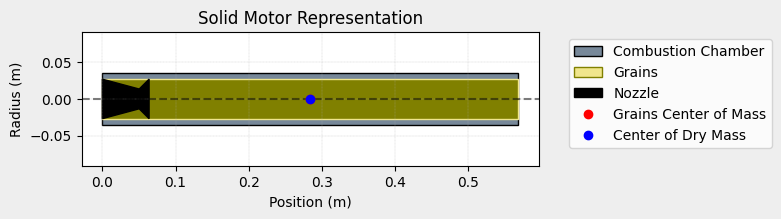

In [359]:
if engine_type[0] == "solid":

  parameter_motor = []

  fill_parameters(parameter_motor, "motor_")
  fill_parameters_exact(parameter_motor, "thrust")
  
  required = [
    "name",
    "total_mass",
    "propellant_mass",
    "diameter",
    "length",
    "burn_time"
  ]
  check_required(parameter_motor, required, "motor")
  
  defaults = {
    "motor_coordinate_system_orientation" : "nozzle_to_combustion_chamber",                # K       # preset (= 25°C)
    "motor_dry_inertia":(0.1, 0.1, 0.001),
    "holddown_time":0,

  }
  add_defaults(parameter_motor, defaults)
  
  print(parameter_motor)


  motors = []

  for motor_vals in generate_combinations(parameter_motor):

    motor_volume            = pi * ((motor_vals["motor_diameter"] /1000 /2) ** 2) * motor_vals["motor_length"] /1000     #m³
    motor_grain_density     = (motor_vals["motor_propellant_mass"] /1000)/motor_volume          #kg/m³

    motor = SolidMotor(
      thrust_source                   = "./" + project + "/" + motor_vals["thrust"],
      dry_mass                        = motor_vals["motor_total_mass"] /1000 - motor_vals["motor_propellant_mass"] /1000,
      dry_inertia                     = motor_vals["motor_dry_inertia"],                        #kg*m²   #guess / not so relevant
      nozzle_radius                   = motor_vals["motor_diameter"] /1000 /2,
      grain_number                    = 1,
      grain_density                   = motor_grain_density,
      grain_outer_radius              = motor_vals["motor_diameter"] /1000 /2,
      grain_initial_inner_radius      = 0,
      grain_initial_height            = motor_vals["motor_length"] /1000,
      grain_separation                = 0,
      grains_center_of_mass_position  = motor_vals["motor_length"] /1000 / 2,
      center_of_dry_mass_position     = motor_vals["motor_length"] /1000 / 2,
      nozzle_position                 = 0,
      burn_time                       = motor_vals["motor_burn_time"],
      throat_radius                   = motor_vals["motor_diameter"] /1000 /2 / 2,
      coordinate_system_orientation   = motor_vals["motor_coordinate_system_orientation"],
    )
    # motor.all_info()

    attach_meta(motor, {
        k: motor_vals[k]
        for k in variables
        if k in motor_vals
    })
    motors.append(motor)
  register("motor", motors)
  motor.draw()

## Rocket components

['rocket_diameter', 'nosecone_length', 'nosecone_kind']


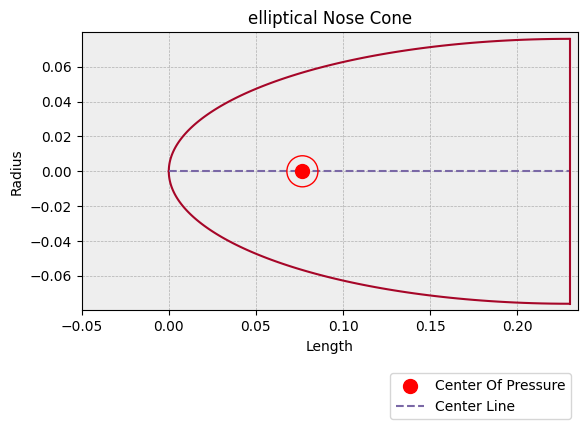

['tailcone_diameter', 'tailcone_length', 'rocket_diameter', 'tailcone_cylindrical_length']
['fins_amount', 'fins_position', 'fins_shape_points', 'rocket_diameter', 'tailcone_diameter', 'fins_name']


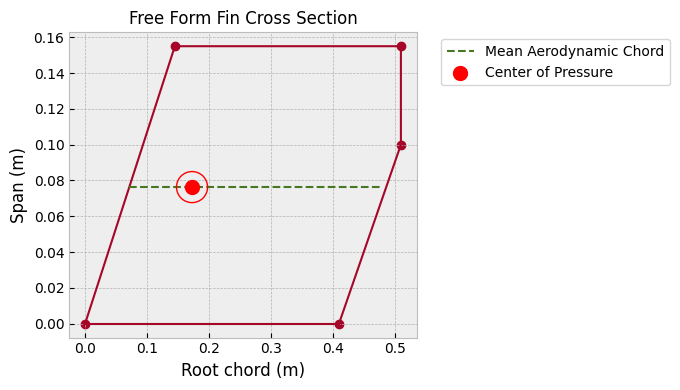

['drogue_cd_s', 'drogue_trigger', 'drogue_lag', 'main_cd_s', 'main_trigger', 'drogue_sampling_rate', 'drogue_noise', 'main_sampling_rate', 'main_lag', 'main_noise']


In [ ]:
parameter_nosecone = []
required = ["length"]
defaults = {"nosecone_kind":"von karman"}
fill_parameters_exact(parameter_nosecone, "rocket_diameter")
fill_parameters(parameter_nosecone, "nosecone_")
check_required(parameter_nosecone, required, "nosecone")
add_defaults(parameter_nosecone, defaults)

print(parameter_nosecone)

nosecones = []

for nosecone_vals in generate_combinations(parameter_nosecone):
    nosecone = NoseCone(
        length = nosecone_vals["nosecone_length"] /1000,
        base_radius = nosecone_vals["rocket_diameter"]/2 /1000,
        kind = nosecone_vals["nosecone_kind"]
    )
    attach_meta(nosecone, {
        k: nosecone_vals[k]
        for k in variables
        if k in nosecone_vals
    })
    nosecones.append(nosecone)
register("nosecone", nosecones)
nosecone.draw()


parameter_tailcone = []
required = ["diameter", "length"]
defaults = {"tailcone_cylindrical_length":0}
fill_parameters(parameter_tailcone, "tailcone_")
fill_parameters_exact(parameter_tailcone, "rocket_diameter")
check_required(parameter_tailcone, required, "tailcone")
add_defaults(parameter_tailcone, defaults)

print(parameter_tailcone)

tailcones = []

for tailcone_vals in generate_combinations(parameter_tailcone):
    tailcone = Tail(
        top_radius = tailcone_vals["rocket_diameter"] /2 /1000,
        bottom_radius = tailcone_vals["tailcone_diameter"] /2 /1000,
        length = tailcone_vals["tailcone_length"] /1000,
        rocket_radius = tailcone_vals["rocket_diameter"]/2 /1000
    )
    attach_meta(tailcone, {
        k: tailcone_vals[k]
        for k in variables
        if k in tailcone_vals
    })
    tailcones.append(tailcone)
register("tailcone", tailcones)


parameter_fins = []

defaults = {"fins_amount" : 4, "fins_name":"fins"}

fill_parameters(parameter_fins, "fins_")
fill_parameters_exact(parameter_fins, ["rocket_diameter","tailcone_diameter"])


if not parameter_fins.__contains__("fins_shape_points"):
    required=[
        "root_chord",
        "tip_chord",
        "span",
        "sweep_length"
    ]
    check_required(parameter_fins, required, "fins")

add_defaults(parameter_fins, defaults)

print(parameter_fins)


fins = []
trapezoidal_fins = []

for fin_vals in generate_combinations(parameter_fins):
    if "fins_shape_points" in parameter_fins:
        fin_set = FreeFormFins(
            n = fin_vals["fins_amount"],
            shape_points = fin_vals["fins_shape_points"],         # m
            rocket_radius=fin_vals["tailcone_diameter"] /2 /1000,    # m
            name = "Freeform"
        )
        # fin_set.draw()
        attach_meta(fin_set, {
            k: fin_vals[k]
            for k in variables
            if k in fin_vals
        })
        fins.append(fin_set)
    else:
        trapezoidal_fin_set = TrapezoidalFins(
            n = fin_vals["fins_amount"],
            root_chord = fin_vals["fins_root_chord"] /1000,      # m
            tip_chord = fin_vals["fins_tip_chord"] /1000,        # m
            span = fin_vals["fins_span"] /1000,                  # m
            sweep_length = fin_vals["fins_sweep_length"] /1000,  # m
            name = fin_vals["fins_name"],
            rocket_radius = fin_vals["rocket_diameter"]/2 /1000 # m
        )
        # trapezoidal_fin_set.draw()
        attach_meta(trapezoidal_fin_set, {
            k: fin_vals[k]
            for k in variables
            if k in fin_vals
        })
        trapezoidal_fins.append(trapezoidal_fin_set)

if "fins_shape_points" in parameter_fins:
    register("fin_set", fins)
    fin_set.draw()
    print(fins)
else:
    register("fin_set", trapezoidal_fins)
    trapezoidal_fin_set.draw()
    print(trapezoidal_fins)


parameter_parachutes = []

required=[
    "cd_s",
    "trigger"
]

defaults = {
    "drogue_sampling_rate": 105,        # hz              # preset
    "drogue_lag": 1,                    # s               # measured
    "drogue_noise": (0, 8.3, 0.5),       # (pa, pa, pa)    # preset
    "main_sampling_rate": 105,        # hz              # preset
    "main_lag": 4,                    # s               # measured
    "main_noise": (0, 8.3, 0.5)        # (pa, pa, pa)    # preset
}

fill_parameters(parameter_parachutes, "drogue_")
fill_parameters(parameter_parachutes, "main_")

check_required(parameter_parachutes, required, "drogue")
check_required(parameter_parachutes, required, "main")

add_defaults(parameter_parachutes, defaults)

print(parameter_parachutes)


parachutes = []

for parachute_vals in generate_combinations(parameter_parachutes):
    parachute_list = {}
    parachute_list[0] = Parachute(
        name = "main",
        cd_s = parachute_vals["main_cd_s"],
        trigger = parachute_vals["main_trigger"],             # m
        sampling_rate = parachute_vals["main_sampling_rate"], # hz
        lag = parachute_vals["main_lag"],                     # s
        noise = parachute_vals["main_noise"],                 # (pa, pa, pa)
    )

    parachute_list[1] = Parachute(
        name = "drogue",
        cd_s = parachute_vals["drogue_cd_s"],
        trigger = parachute_vals["drogue_trigger"],             # m
        sampling_rate = parachute_vals["drogue_sampling_rate"], # hz
        lag = parachute_vals["drogue_lag"],                     # s
        noise = parachute_vals["drogue_noise"],                 # (pa, pa, pa)
    )
    attach_meta(parachute_list[0], {
        k: parachute_vals[k]
        for k in variables
        if k in parachute_vals
    })
    attach_meta(parachute_list[1], {
        k: parachute_vals[k]
        for k in variables
        if k in parachute_vals
    })
    parachutes.append(parachute_list)
register("parachutes", parachutes)


## Rocket

['rocket_length', 'rocket_diameter', 'rocket_dry_mass', 'rocket_CG', 'rocket_moment_of_intertia_Z', 'rocket_moment_of_intertia_XY', 'railbuttons_upper', 'railbuttons_lower', 'fins_position', 'tailcone_length', 'tailcone_cylindrical_length', 'motor', 'nosecone', 'tailcone', 'fin_set', 'parachutes', 'nozzle_position']


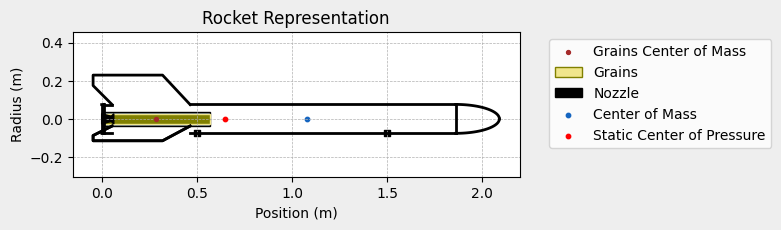

In [361]:
# add MOI to defaults or required

parameter_rockets = []

required=[
    "diameter",
    "dry_mass",
    "CG",
    "length"
]
defaults={"nozzle_position":0}

fill_parameters(parameter_rockets, "rocket_")
fill_parameters(parameter_rockets, "railbuttons_")
fill_parameters_exact(parameter_rockets, [
    "nozzle_position",
    "fins_position",
    "tailcone_length",
    "tailcone_cylindrical_length",
    "motor",
    "nosecone",
    "tailcone",
    "fin_set",
    "parachutes"])
check_required(parameter_rockets, required, "rocket")
add_defaults(parameter_rockets, defaults)

print(parameter_rockets)

rockets = []

for rocket_vals in generate_combinations(parameter_rockets):
    rocket = Rocket(
        radius = rocket_vals["rocket_diameter"] /2 / 1000,                      # m
        mass = rocket_vals["rocket_dry_mass"] / 1000,                                # m
        inertia = (rocket_vals["rocket_moment_of_intertia_XY"], rocket_vals["rocket_moment_of_intertia_XY"], rocket_vals["rocket_moment_of_intertia_Z"]),  # kg * m^2
        power_off_drag = "./" + project + "/power_off_drag.csv",
        power_on_drag = "./" + project + "/power_on_drag.csv",
        center_of_mass_without_motor = rocket_vals["rocket_CG"] / 1000,                # m
        coordinate_system_orientation = "tail_to_nose"
    )
    rocket.add_motor(rocket_vals["motor"], position = rocket_vals["nozzle_position"] /1000)
    rocket.set_rail_buttons(upper_button_position= rocket_vals["railbuttons_upper"] / 1000, lower_button_position=rocket_vals["railbuttons_lower"] / 1000)
    rocket.add_surfaces(surfaces=[rocket_vals["nosecone"], rocket_vals["fin_set"], rocket_vals["tailcone"]], positions=[rocket_vals["rocket_length"] / 1000, rocket_vals["fins_position"] / 1000, rocket_vals["tailcone_length"] / 1000])

    rocket.parachutes = list(rocket_vals["parachutes"].values())

    #hedy.all_info()
    attach_meta(rocket, {
        k: rocket_vals[k]
        for k in variables
        if k in rocket_vals
    })
    rockets.append(rocket)
register("rocket", rockets)

vis_args = {
    "background": "#EEEEEE",
    "tail": "black",
    "nose": "black",
    "body": "black",
    "fins": "black",
    "motor": "black",
    "buttons": "black",
    "line_width": 2.0,
}
rocket.draw(plane = 'xz', vis_args = vis_args)

## Flight

In [362]:
parameter_flights = []

required = [
    "rail_length",
    "inclination",
    "heading"
]

defaults = {
  "flight_terminate_on_apogee" : True
}

fill_parameters(parameter_flights, "flight_")
fill_parameters_exact(parameter_flights, "rocket")
check_required(parameter_flights, required, "flight")
add_defaults(parameter_flights, defaults)

print(parameter_flights)

for type in enabled_env_types:
  parameter_flights.append("env" + type)


flights_normal = []
flights_forecast = []
flights_custom = []
flights_reanalysis = []

def count_combinations(params):
    return prod(
        len(variables[p]) for p in params if p in variables
    ) or 1

total = count_combinations(parameter_flights)
step = max(1, total // 10)
print(total)

for i, flight_vals in enumerate(generate_combinations(parameter_flights), start=1):

  if "Normal" in enabled_env_types:
    flight_normal = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envNormal"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Normal"
    )
    #flight_normal.prints.out_of_rail_conditions()
    #flight_normal.prints.apogee_conditions()
    #flight_normal.prints.impact_conditions()
    #flight_normal.prints.maximum_values()
    #flight_normal.plots.trajectory_3d()
    #flight_normal.plots.stability_and_control_data()

    #flight_normal.plots.all()
    #flight_normal.prints.all()
    #flight_normal.all_info()
    attach_meta(flight_normal, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_normal.append(flight_normal)


  if "Forecast" in enabled_env_types:
    flight_forecast = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envForecast"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Forecast"
    )
    #flight_forecast.prints.out_of_rail_conditions()
    #flight_forecast.prints.apogee_conditions()
    #flight_forecast.prints.impact_conditions()
    #flight_forecast.prints.maximum_values()
    #flight_forecast.plots.trajectory_3d()
    #flight_forecast.plots.stability_and_control_data()

    #flight_forecast.prints.all()
    #flight_forecast.plots.all()
    #flight_forecast.all_info()
    attach_meta(flight_forecast, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_forecast.append(flight_forecast)
  if "Custom" in enabled_env_types:
    flight_custom = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envCustom"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Custom"
    )
    #flight_custom.prints.out_of_rail_conditions()
    #flight_custom.prints.apogee_conditions()
    #flight_custom.prints.impact_conditions()
    #flight_custom.prints.maximum_values()
    #flight_custom.plots.trajectory_3d()
    #flight_custom.plots.stability_and_control_data()

    #flight_custom.prints.all()
    #flight_custom.plots.all()
    #flight_custom.all_info()
    attach_meta(flight_custom, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_custom.append(flight_custom)
  
  if "Reanalysis" in enabled_env_types:
    flight_reanalysis = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envReanalysis"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Reanalysis"
    )
    #flight_reanalysis.prints.out_of_rail_conditions()
    #flight_reanalysis.prints.apogee_conditions()
    #flight_reanalysis.prints.impact_conditions()
    #flight_reanalysis.prints.maximum_values()
    #flight_reanalysis.plots.trajectory_3d()
    #flight_reanalysis.plots.stability_and_control_data()

    #flight_reanalysis.prints.all()
    #flight_reanalysis.plots.all()
    #flight_reanalysis.all_info()
    attach_meta(flight_reanalysis, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_reanalysis.append(flight_reanalysis)

  if i % step == 0 or i == total:
      print(f"{i / total:.0%}")
  
register("normal_flight", flights_normal)
register("forecast_flight", flights_forecast)
register("custom_flight", flights_custom)
register("reanalysis_flight", flights_reanalysis)
#flight_forecast.all_info()

['flight_rail_length', 'flight_inclination', 'flight_heading', 'rocket', 'flight_terminate_on_apogee']
15
7%
13%
20%
27%
33%
40%
47%
53%
60%
67%
73%
80%
87%
93%
100%


## Deployable Payloads (for CANSAT)

CanSat Weight: 300 - 350 g \
CanSat Radius: 66 mm \
CanSat Length: 115 mm \
CanSats per launch: 6 \
6 x 300 g = 1800 g

### Rocket

In [363]:
# w_p = without payload
if project == "CANSAT":
    parameter_rockets_w_p = []
    required=[
        "payload_mass_total", 
        "rocket"
    ]
    fill_parameters_exact(parameter_rockets_w_p, ["payload_mass_total", "rocket"])
    check_required(parameter_rockets_w_p, required)

    print(parameter_rockets_w_p)

    rockets_w_p = []

    for rocket_w_p_vals in generate_combinations(parameter_rockets_w_p):
        rocket_w_p = {}
        rocket_w_p["nominal"] = copy.deepcopy(rocket_w_p_vals["rocket"])
        rocket_w_p["nominal"].mass -= rocket_w_p_vals["payload_mass_total"]

        rocket_w_p["no_main"] = copy.deepcopy(rocket_w_p["nominal"])
        rocket_w_p["no_main"].parachutes.pop()
        rocket_w_p["ballistic"] = copy.deepcopy(rocket_w_p["no_main"])
        rocket_w_p["ballistic"].parachutes.clear()

        attach_meta(rocket_w_p["nominal"], {
            k: rocket_w_p_vals[k]
            for k in variables
            if k in rocket_w_p_vals
        })
        attach_meta(rocket_w_p["no_main"], {
            k: rocket_w_p_vals[k]
            for k in variables
            if k in rocket_w_p_vals
        })
        attach_meta(rocket_w_p["ballistic"], {
            k: rocket_w_p_vals[k]
            for k in variables
            if k in rocket_w_p_vals
        })
        rockets_w_p.append(rocket_w_p)
    register("rocket_without_payload", rockets_w_p)


['payload_mass_total', 'rocket']


### Flight without payload

In [364]:
# w_p = without payload

if project == "CANSAT":
    def ensure_list(obj):
        if obj is None:
            return []
        if isinstance(obj, (list, tuple, set)):
            return list(obj)
        return [obj]
    all_flights = [flight
    for key in ["normal_flight", "forecast_flight", "custom_flight", "reanalysis_flight"]
    for flight in ensure_list(lookup(key)[0])]

    register("all_flights", all_flights)

    
    parameter_flight_w_p = []
    
    fill_parameters_exact(parameter_flight_w_p, "rocket_without_payload")
    fill_parameters_exact(parameter_flight_w_p, "all_flights")

    print(parameter_flight_w_p)

    flights_w_p = []
    flights_w_p_no_main = []
    flights_w_p_ballistic = []
    total = count_combinations(parameter_flight_w_p)
    step = max(1, total // 10)
    print(total*3)

    for i, flight_w_p_vals in enumerate(generate_combinations(parameter_flight_w_p), start=1):
        flight_w_p = Flight(
            rocket        = flight_w_p_vals["rocket_without_payload"]["nominal"],
            environment   = flight_w_p_vals["all_flights"].env,
            rail_length   = flight_w_p_vals["all_flights"].rail_length,
            inclination   = flight_w_p_vals["all_flights"].inclination,
            heading       = flight_w_p_vals["all_flights"].heading,
            terminate_on_apogee = False,
            initial_solution = flight_w_p_vals["all_flights"],
            name          = "Rocket_touchdown_nominal"
        )

        flight_w_p_no_main = Flight(
            rocket        = flight_w_p_vals["rocket_without_payload"]["no_main"],
            environment   = flight_w_p_vals["all_flights"].env,
            rail_length   = flight_w_p_vals["all_flights"].rail_length,
            inclination   = flight_w_p_vals["all_flights"].inclination,
            heading       = flight_w_p_vals["all_flights"].heading,
            terminate_on_apogee = False,
            initial_solution = flight_w_p_vals["all_flights"],
            name          = "Rocket_touchdown_no_main"
        )

        flight_w_p_ballistic = Flight(
            rocket        = flight_w_p_vals["rocket_without_payload"]["ballistic"],
            environment   = flight_w_p_vals["all_flights"].env,
            rail_length   = flight_w_p_vals["all_flights"].rail_length,
            inclination   = flight_w_p_vals["all_flights"].inclination,
            heading       = flight_w_p_vals["all_flights"].heading,
            terminate_on_apogee = False,
            initial_solution = flight_w_p_vals["all_flights"],
            name          = "Rocket_touchdown_ballistic"
        )

        attach_meta(flight_w_p, {
            k: flight_w_p_vals[k]
            for k in variables
            if k in flight_w_p_vals
        })

        attach_meta(flight_w_p_no_main, {
            k: flight_w_p_vals[k]
            for k in variables
            if k in flight_w_p_vals
        })

        attach_meta(flight_w_p_ballistic, {
            k: flight_w_p_vals[k]
            for k in variables
            if k in flight_w_p_vals
        })
        flights_w_p.append(flight_w_p) 
        flights_w_p_no_main.append(flight_w_p_no_main) 
        flights_w_p_ballistic.append(flight_w_p_ballistic)      
        if i % step == 0 or i == total:
            print(f"{i / total:.0%}")
    register("flight_without_payload", flights_w_p)
    register("flight_without_payload_no_main", flights_w_p_no_main)
    register("flight_without_payload_ballistic", flights_w_p_ballistic)


['rocket_without_payload', 'all_flights']
90
10%
20%
30%
40%
50%
60%
70%
80%
90%
100%


### Payload parachute

In [366]:
if project == "CANSAT":
    parameter_payload_parachute = []

    required=[
        "cd_s",
        "trigger"
    ]

    defaults = {
        "sampling_rate": 105,        # hz              # preset
        "lag": 1,                    # s               # measured
        "noise": (0, 8.3, 0.5)       # (pa, pa, pa)    # preset
    }
    fill_parameters(parameter_payload_parachute, "parachute_payload_")

    check_required(parameter_payload_parachute, required, "parachute_payload")

    add_defaults(parameter_payload_parachute, defaults, "parachute_payload")

    print(parameter_payload_parachute)

    payload_parachutes = []

    for parachute_vals in generate_combinations(parameter_payload_parachute):
        parachute_list = {}
        parachute_list[0] = Parachute(
            name = "parachute_payload",
            cd_s = parachute_vals["parachute_payload_cd_s"],
            trigger = parachute_vals["parachute_payload_trigger"],             # m
            sampling_rate = parachute_vals["parachute_payload_sampling_rate"], # hz
            lag = parachute_vals["parachute_payload_lag"],                     # s
            noise = parachute_vals["parachute_payload_noise"],                 # (pa, pa, pa)
        )
        attach_meta(parachute_list[0], {
            k: parachute_vals[k]
            for k in variables
            if k in parachute_vals
        })
        payload_parachutes.append(parachute_list)
    register("payload_parachute", payload_parachutes)


['parachute_payload_trigger', 'parachute_payload_cd_s', 'parachute_payload_sampling_rate', 'parachute_payload_lag', 'parachute_payload_noise']


### Payload

In [367]:
if project == "CANSAT":
    parameter_payload = []

    required=[
        "diameter",
        "mass",
        "length"
    ]
    defaults={
        "payload_moment_of_intertia_XY":0.01,
        "payload_moment_of_intertia_Z":0.01
    }

    fill_parameters(parameter_payload, "payload_")
    check_required(parameter_payload, required, "payload")
    add_defaults(parameter_payload, defaults)

    print(parameter_payload)

    payloads = []

    for payload_vals in generate_combinations(parameter_payload):
        payload = {}
        payload["nominal"] = Rocket(
            radius = payload_vals["payload_diameter"] /2 / 1000,                      # m
            mass = payload_vals["payload_mass"] / 1000,                                # m
            inertia = (payload_vals["payload_moment_of_intertia_XY"], payload_vals["payload_moment_of_intertia_XY"], payload_vals["payload_moment_of_intertia_Z"]),  # kg * m^2
            power_off_drag = "./" + project + "/power_off_drag.csv",
            power_on_drag = "./" + project + "/power_off_drag.csv",
            center_of_mass_without_motor = payload_vals["payload_length"] / 2 / 1000,                # m
            coordinate_system_orientation = "tail_to_nose"
        )

        # to add a payload with no chute, insert a payload "Rocket" into the dict, which has no chute
        # this could cause issues, as a payload "Rocket" without chutes has no aerodynamic surface
        
        payload["nominal"].parachutes = list(payload_vals["payload_parachute"].values())



        attach_meta(payload["nominal"], {
            k: payload_vals[k]
            for k in variables
            if k in payload_vals
        })
        payloads.append(payload)
    register("payload", payloads)

['payload_mass_total', 'payload_diameter', 'payload_length', 'payload_mass', 'payload_parachute', 'payload_moment_of_intertia_XY', 'payload_moment_of_intertia_Z']


### Payload flight

In [368]:
if project == "CANSAT":
    parameter_payload_flights = []
    fill_parameters_exact(parameter_payload_flights, "all_flights")
    fill_parameters_exact(parameter_payload_flights, "payload")

    print(parameter_payload_flights)

    flights_payload = []

    total = count_combinations(parameter_payload_flights)
    step = max(1, total // 10)
    print(total)

    for i, flight_payload_vals in enumerate(generate_combinations(parameter_payload_flights), start=1):
        flight_payload = Flight(
            rocket        = flight_payload_vals["payload"]["nominal"],
            environment   = flight_payload_vals["all_flights"].env,
            rail_length   = flight_payload_vals["all_flights"].rail_length,
            inclination   = flight_payload_vals["all_flights"].inclination,
            heading       = flight_payload_vals["all_flights"].heading,
            terminate_on_apogee = False,
            initial_solution = flight_payload_vals["all_flights"],
            name          = "Payload"
        )

        attach_meta(flight_payload, {
            k: flight_payload_vals[k]
            for k in variables
            if k in flight_payload_vals
        })
        flights_payload.append(flight_payload)    
        if i % step == 0 or i == total:
            print(f"{i / total:.0%}")
    register("flight_payload", flights_payload)


['all_flights', 'payload']
720
10%
20%
30%
40%
50%
60%
70%
80%
90%
100%


In [369]:
print(parameter_payload_flights)
print(len(all_flights))
print(count_combinations(parameter_payload))
print(count_combinations(parameter_payload_flights))

['all_flights', 'payload']
30
24
720


# Comparsion

Plot saved to file: 2d_xy.png
Plot saved to file: 2d_yz.png


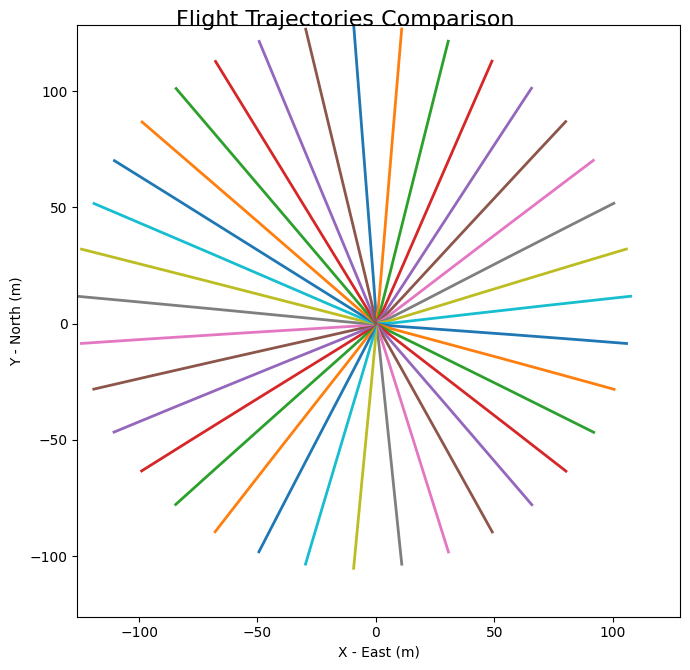

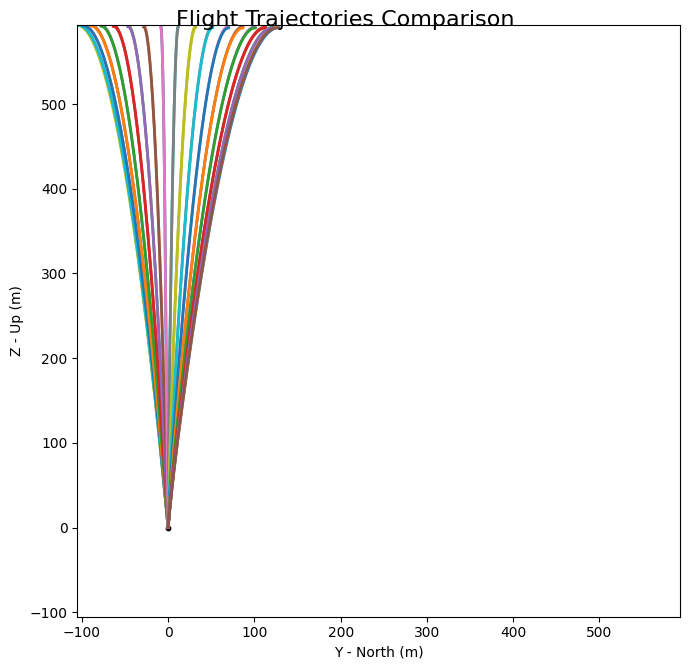

In [ ]:
legend = False
all_flights = lookup("all_flights")[0]

#for flight in all_flights:
#    print(flight.name)
    # print(flight._meta)
comparison_normal = CompareFlights(all_flights)
comparison_normal.trajectories_3d(legend=legend, filename = "3d.png")
comparison_normal.trajectories_2d(legend=legend, filename = "2d_xy.png", plane = "xy")
comparison_normal.trajectories_2d(legend=legend, filename = "2d_xz.png", plane = "xz")
comparison_normal.trajectories_2d(legend=legend, filename = "2d_yz.png", plane = "yz")

In [46]:
# DEBUG

print(flights_reanalysis[0].rocket.motor.total_impulse)
#print(flights_reanalysis[7].rocket.motor.total_impulse)
#flights_reanalysis[7].all_info()
#flights_reanalysis[0].all_info()

2240.432540928571


## Comparsion CANSAT

In [208]:
def scale_zones(zones, scale_factor):
    """
    scale_factor > 1  -> enlarge
    scale_factor = 1  -> unchanged
    scale_factor < 1  -> shrink
    """
    enlarged = {}

    for zone_name, coordinates in zones.items():
        # Calculate centroid (average of points)
        cx = sum(x for x, y in coordinates) / len(coordinates)
        cy = sum(y for x, y in coordinates) / len(coordinates)

        new_coords = []
        for x, y in coordinates:
            # Vector from center to point
            dx = x - cx
            dy = y - cy

            # Scale vector
            new_x = cx + dx * scale_factor
            new_y = cy + dy * scale_factor

            new_coords.append((new_x, new_y))

        enlarged[zone_name] = new_coords

    return enlarged

# ===============================
# Function to plot polygons
# ===============================
def plot_zones(ax, zones, color='red', alpha=0.3):
    for name, coords in zones.items():
        polygon = Polygon(coords, closed=True, facecolor=color, edgecolor=color, alpha=alpha)
        ax.add_patch(polygon)
    # Adjust limits
    all_x = [x for coords in zones.values() for x, y in coords]
    all_y = [y for coords in zones.values() for x, y in coords]
    ax.set_xlim(min(all_x) - 50, max(all_x) + 50)
    ax.set_ylim(min(all_y) - 50, max(all_y) + 50)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

# ===============================
# Function to plot flight impacts
# ===============================
def plot_flights(ax, flight_groups):
    """
    flight_groups = {
        "rocket_nominal": (flights, "green"),
        "rocket_no_main": (flights, "orange"),
        "rocket_ballistic": (flights, "red"),
        "payload_nominal": (flights, "blue"),
    }
    """
    for label, (flights, color) in flight_groups.items():
        xs = [f.x_impact for f in flights]
        ys = [f.y_impact for f in flights]
        ax.scatter(xs, ys, color=color, label=label)

    ax.scatter(0, 0, color="black", marker="x", label="launch rail")
    ax.legend()

# ===============================
# Function to plot everything together
# ===============================
def plot_all(name, exclusion_zones=None, buffer_zones=None, flight_groups=None):
    fig, ax = plt.subplots()

    if exclusion_zones:
        plot_zones(ax, exclusion_zones, color="red")
    if buffer_zones:
        plot_zones(ax, buffer_zones, color="orange")

    if flight_groups:
        plot_flights(ax, flight_groups)

    fig.savefig(f"plots/{name}.png", dpi=300, bbox_inches="tight")
    #plt.show()

def is_in_exclusion_zone(coords, zones_dict):
    """
    Check which points are inside any of the exclusion zones.

    Parameters
    ----------
    coords : array-like of (x, y) tuples
        [(x1, y1), (x2, y2), ...]
    zones_dict : dict
        {"zone_name": [(x1,y1), (x2,y2), ...], ...}

    Returns
    -------
    inside_mask : np.ndarray (bool)
        True if point is inside ANY zone
    """
    points = np.asarray(coords)  # shape (N, 2)
    inside_mask = np.zeros(len(points), dtype=bool)

    for zone_coords in zones_dict.values():
        path = Path(zone_coords)
        inside_mask |= path.contains_points(points)

    return inside_mask

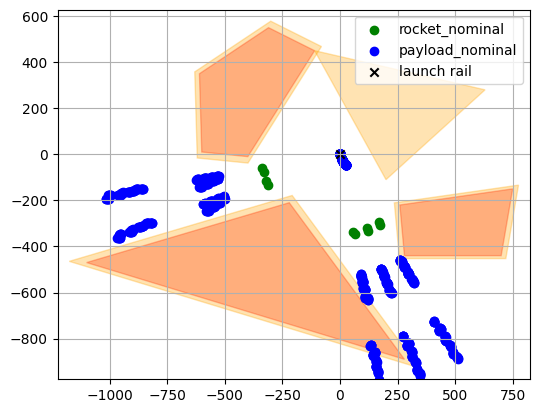

In [370]:
if project == "CANSAT":
    # Define polygons (x = WO, y = NS)
    exclusion_zones = {
        "Exclusion Zone Flughafen": [
            (-110, 450),
            (-310, 550),
            (-610, 350),
            (-600, 10),
            (-400, -10),
            #(0,0)   # enable to exclude launches heading to tribune
        ],
        "Exclusion Zone Niederham": [
            (-1100, -470),
            (-220, -210),
            (280, -890)
        ],
        "Rehwinkl": [
            (260, -220),
            (750, -150),
            (700, -440),
            (280, -440)
        ]
    }
    buffer_zones = {
        "Buffer Zone Wald": [
            (-110, 450),
            (200, -110),
            (630, 280)
        ]
    }

    dummy_zones = {
        "dummy": [
            (-750,400),
            (250,-200),
            (400,400)
        ]
    }

    buffer_zones.update(scale_zones(exclusion_zones, 1.1))
    plot_all("all_figures", exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (flights_w_p, "green"),
        "payload_nominal": (flights_payload, "blue")
    })


In [92]:
print(len(lookup("forecast_flight")[0]))
print(len(lookup("normal_flight")[0]))

16
0


Safe heading: 150
Safe heading: 160
Safe heading: 250
Safe heading: 260


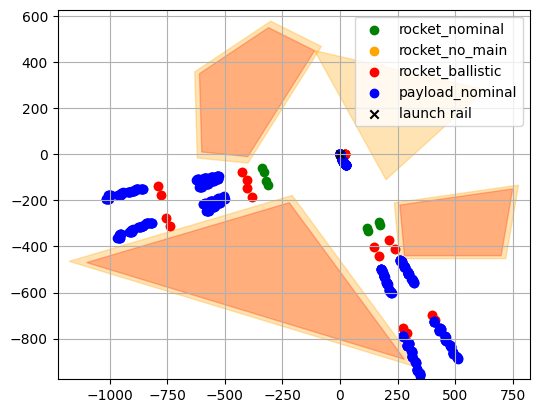

In [373]:
if project == "CANSAT":
    zones = exclusion_zones
    # ===============================
    # Prepare coordinates as tuples
    # ===============================

    all_payload_scenarios = flights_payload
    all_rocket_scenarios = flights_w_p + flights_w_p_no_main + flights_w_p_ballistic

    payload_coords = [(f.x_impact, f.y_impact) for f in flights_payload]
    rocket_coords  = [(f.x_impact, f.y_impact) for f in flights_w_p]
    rocket_coords_no_main  = [(f.x_impact, f.y_impact) for f in flights_w_p_no_main]
    rocket_coords_ballistic  = [(f.x_impact, f.y_impact) for f in flights_w_p_ballistic]

    # ===============================
    # Check which impacts are in exclusion zones
    # ===============================
    payload_impacts = is_in_exclusion_zone(payload_coords, zones)
    rocket_impacts  = is_in_exclusion_zone(rocket_coords, zones)
    no_main_impacts  = is_in_exclusion_zone(rocket_coords_no_main, zones)
    ballistic_impacts  = is_in_exclusion_zone(rocket_coords_ballistic, zones)

    # ===============================
    # Find headings of payloads in exclusion zones
    # ===============================
    payload_headings_in_zone = list({flights_payload[i].heading 
                            for i, in_zone in enumerate(payload_impacts) if in_zone})

    # ===============================
    # Find headings of rockets in exclusion zones
    # ===============================
    rocket_headings_in_zone = list({flights_w_p[i].heading 
                            for i, in_zone in enumerate(rocket_impacts) if in_zone})
    no_main_headings_in_zone = list({flights_w_p_no_main[i].heading 
                            for i, in_zone in enumerate(no_main_impacts) if in_zone})
    ballistic_headings_in_zone = list({flights_w_p_ballistic[i].heading 
                            for i, in_zone in enumerate(ballistic_impacts) if in_zone})

    #print("Headings with payload in exclusion zones:", payload_headings_in_zone)
    #print("Headings with rocket in exclusion zones:", rocket_headings_in_zone)
    #print("Headings with rocket no main in exclusion zones:", no_main_headings_in_zone)
    #print("Headings with ballistic rocket in exclusion zones:", ballistic_headings_in_zone)

    # ===============================
    # Print headings not in exclusion zones
    # ===============================
    all_headings = lookup("flight_heading")[0]
    for i in all_headings:
        if (i not in payload_headings_in_zone) and (i not in rocket_headings_in_zone + ballistic_headings_in_zone +  no_main_headings_in_zone):
            print("Safe heading:", i)

    # -------------------------------
    # 1) Compute forbidden headings
    # -------------------------------
    safe_payload_headings = [
        h for h in all_headings
        if h not in payload_headings_in_zone
    ]

    safe_rocket_headings = [
        h for h in all_headings
        if h not in rocket_headings_in_zone
        and h not in no_main_headings_in_zone
        and h not in ballistic_headings_in_zone
    ]
    # -------------------------------
    # 2) Filter safe flights by heading
    # -------------------------------
    safe_payload_nominal = [
        f for f in flights_payload
        if f.heading in safe_payload_headings
    ]

    safe_rocket_nominal = [
        f for f in flights_w_p
        if f.heading in safe_rocket_headings
    ]

    safe_rocket_no_main = [
        f for f in flights_w_p_no_main
        if f.heading in safe_rocket_headings
    ]

    safe_rocket_ballistic = [
        f for f in flights_w_p_ballistic
        if f.heading in safe_rocket_headings
    ]

    # -------------------------------
    # 3) Find initial solutions that are safe for BOTH
    # -------------------------------
    payload_solutions = (
        [f.initial_solution for f in safe_payload_nominal]
    )

    rocket_solutions = (
        [f.initial_solution for f in safe_rocket_nominal] +
        [f.initial_solution for f in safe_rocket_no_main] +
        [f.initial_solution for f in safe_rocket_ballistic]
    )

    safe_solutions = [s for s in payload_solutions if s in rocket_solutions]

    # -------------------------------
    # 4) Keep only flights belonging to safe solutions
    # -------------------------------
    safe_payload_nominal = [
        f for f in safe_payload_nominal
        if f.initial_solution in safe_solutions
    ]

    safe_rocket_nominal = [
        f for f in safe_rocket_nominal
        if f.initial_solution in safe_solutions
    ]

    safe_rocket_no_main = [
        f for f in safe_rocket_no_main
        if f.initial_solution in safe_solutions
    ]

    safe_rocket_ballistic = [
        f for f in safe_rocket_ballistic
        if f.initial_solution in safe_solutions
    ]

    safe_configurations = list({
        (f.heading, f.inclination)
        for f in safe_rocket_nominal
    })


    # ===============================
    # Plot safe flights with zones
    # ===============================
    plot_all("final", exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (safe_rocket_nominal, "green"),
        "rocket_no_main": (safe_rocket_no_main, "orange"),
        "rocket_ballistic": (safe_rocket_ballistic, "red"),
        "payload_nominal": (safe_payload_nominal, "blue"),
    }
)

In [352]:
grouped = {}

for f in safe_payload_nominal:
    if f.heading not in grouped:
        grouped[f.heading] = set()   # use set for uniqueness
    grouped[f.heading].add(f.inclination)

for heading, inclinations in grouped.items():
    print(f"Heading {heading}: {sorted(inclinations)}")

Heading 150.0: [84.0, 86.0, 88.0, 90.0]
Heading 160.0: [84.0, 86.0, 88.0, 90.0]
Heading 170.0: [84.0, 86.0, 88.0, 90.0]
Heading 250.0: [84.0, 86.0, 88.0, 90.0]
Heading 260.0: [84.0, 86.0, 88.0, 90.0]


Plot saved to file: 2d_xy.png
Plot saved to file: 2d_yz.png


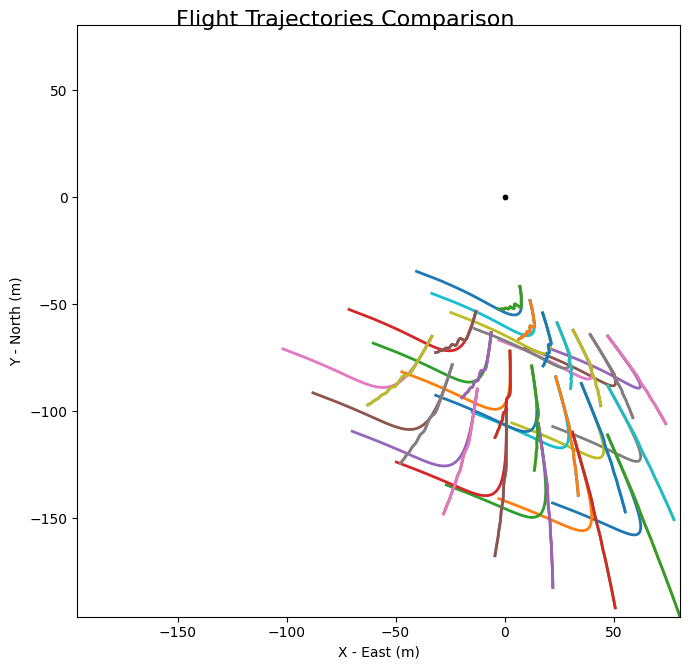

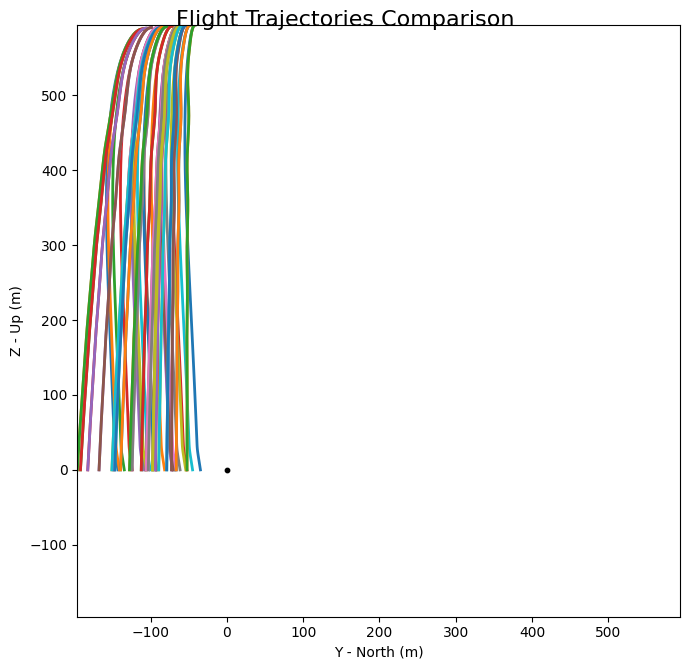

In [ ]:
if project == "CANSAT":
    legend = False
    all_safe_flights = all_safe_flights_payload + all_safe_flights_rocket + all_safe_flights_initial_solutions

    #for flight in all_flights:
        # print(flight.name)
        # print(flight._meta)
    comparison_normal = CompareFlights(all_safe_flights_rocket)
    comparison_normal.trajectories_3d(legend=legend, filename = "3d.png")
    comparison_normal.trajectories_2d(legend=legend, filename = "2d_xy.png", plane = "xy")
    comparison_normal.trajectories_2d(legend=legend, filename = "2d_xz.png", plane = "xz")
    comparison_normal.trajectories_2d(legend=legend, filename = "2d_yz.png", plane = "yz")